**RUN BELOW WITH ALREADY TRAINED YOLO MODEL AND CNNs**

**LOADING PACKAGES AND DATASET**

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.5 MB/s eta 0:00:00


In [5]:
from ultralytics import YOLO

import gdown

file_id = "1s-m6kymo4Ob5_sulFJ_2TiG-gZ-NlkWT"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "best.pt", quiet=False)

model = YOLO('best.pt')

Downloading...
From: https://drive.google.com/uc?id=1s-m6kymo4Ob5_sulFJ_2TiG-gZ-NlkWT
To: /content/best.pt
100%|██████████| 6.25M/6.25M [00:00<00:00, 41.6MB/s]


In [6]:
file_id = "1R_dRzF-X1R4dZm2u5cSfza6KiootRz-1"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "frisbee_dotmaps_cnn_resnet18.pth", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1R_dRzF-X1R4dZm2u5cSfza6KiootRz-1
From (redirected): https://drive.google.com/uc?id=1R_dRzF-X1R4dZm2u5cSfza6KiootRz-1&confirm=t&uuid=b3c0b2ee-8bfa-4fad-959d-6d7ae17546ed
To: /content/frisbee_dotmaps_cnn_resnet18.pth
100%|██████████| 44.8M/44.8M [00:01<00:00, 40.5MB/s]


'frisbee_dotmaps_cnn_resnet18.pth'

In [7]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

YOLO_PATH       = 'best.pt'
CLASSIFIER_PATH = 'frisbee_dotmaps_cnn_resnet18.pth'

yolo_model = YOLO(YOLO_PATH)

checkpoint  = torch.load(CLASSIFIER_PATH)
classes     = checkpoint['classes']
num_classes = len(classes)

classifier = models.resnet18(weights=None)
classifier.fc = nn.Linear(classifier.fc.in_features, num_classes)
classifier.load_state_dict(checkpoint['model_state_dict'])
classifier = classifier.to(device)
classifier.eval()

print("Classes:", classes)
print("Classifier loaded successfully")

Classes: ['32Twist', 'Dominator', 'Dump', 'Flash', 'Go', 'HoStack', 'Wheel']
Classifier loaded successfully


**FINAL FUNCTION TO CLASSIFY ANY IMAGE**

In [8]:
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

COLORS = {0: (0, 165, 255), 1: (0, 0, 255), 2: (0, 255, 0)}
RADII  = {0: 6, 1: 12, 2: 12}

def predict_play(image_path):
    res = yolo_model.predict(image_path, conf=0.3, verbose=False)[0]
    annotated = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)

    size = (640, 640)
    dot_map = np.ones((size[1], size[0], 3), dtype=np.uint8) * 255
    sh = res.orig_shape
    for box in res.boxes:
        cls, (cx, cy, _, _) = int(box.cls), box.xywh[0].tolist()
        px = int(cx * (size[0] / sh[1]))
        py = int(cy * (size[1] / sh[0]))
        if cls in COLORS:
            cv2.circle(dot_map, (px, py), RADII[cls], COLORS[cls], -1)
    dot_map_rgb = cv2.cvtColor(dot_map, cv2.COLOR_BGR2RGB)

    pil_img = Image.fromarray(dot_map_rgb)
    tensor  = infer_transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = classifier(tensor)
        probs  = torch.softmax(output, dim=1)[0]
        top3   = probs.topk(3)

    pred_label = classes[probs.argmax().item()]
    confidence = probs.max().item()

    orig = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(orig)
    axes[0].set_title("Step 1: Original Image", fontsize=13)
    axes[0].axis('off')

    axes[1].imshow(annotated)
    axes[1].set_title("Step 2: YOLO Detections", fontsize=13)
    axes[1].axis('off')

    axes[2].imshow(dot_map_rgb)
    axes[2].set_title("Step 3: Dot Map", fontsize=13)
    axes[2].axis('off')

    plt.suptitle(
        f"Predicted Play: {pred_label} ({confidence:.0%} confidence)\n"
        f"Top 3: " + " | ".join([f"{classes[i]} ({probs[i]:.0%})" for i in top3.indices]),
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    return pred_label, confidence


Saving Test5.png to Test5.png
Classifying /content/Test5.png


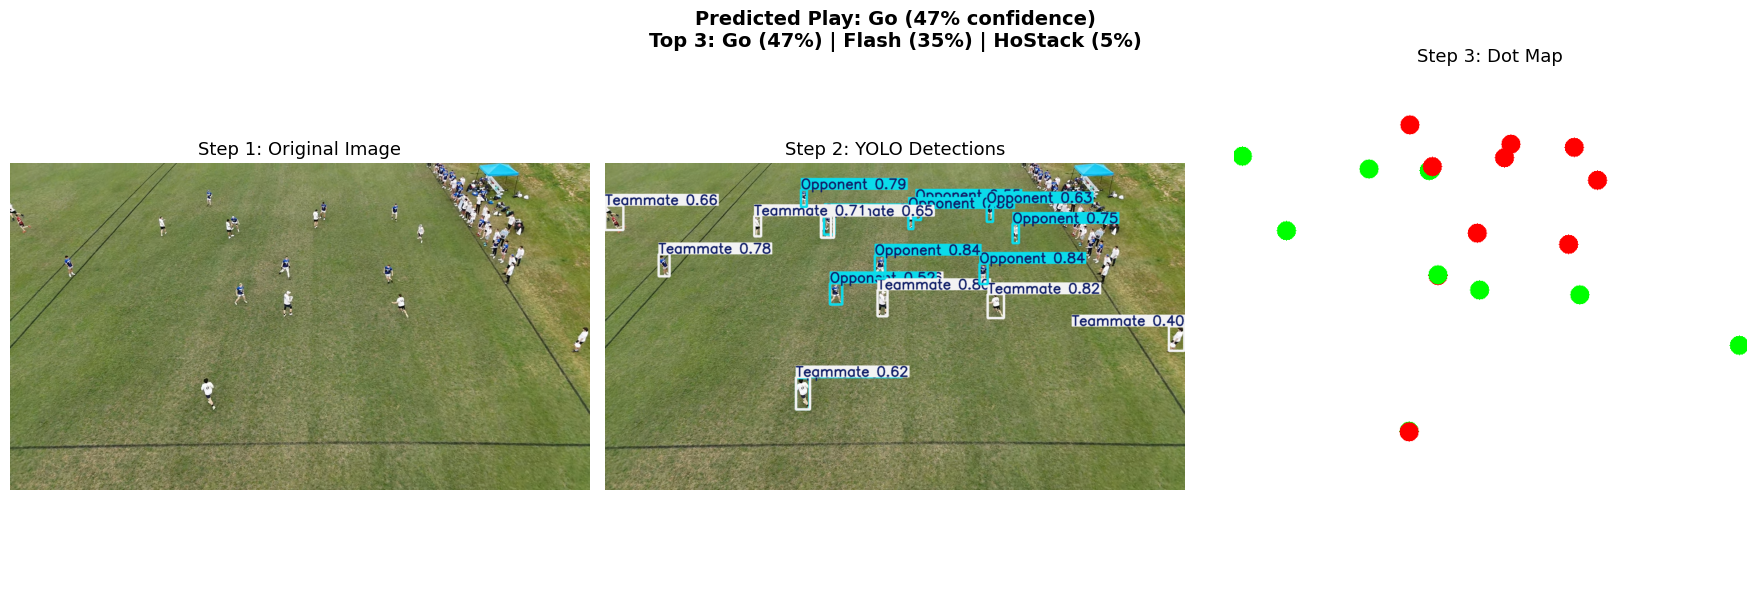

In [9]:
from google.colab import files
import os

uploaded = files.upload()

for filename in uploaded.keys():
    image_path = os.path.abspath(filename)
    print(f"Classifying {image_path}")
    predict_play(image_path)


**BELOW IS ONLY NECESSARY FOR TRAINING MODELS**

**LOADING/CHECKING DATA**

In [ ]:
!pip install roboflow

from roboflow import Roboflow
api_key = input("Enter your Roboflow API key: ")
rf = Roboflow(api_key=api_key)
project = rf.workspace("colins-workspace-zcf3w").project("frisbee-5swwf")
version = project.version(2)
dataset = version.download("yolov8")


Enter your Roboflow API key: vDI71bUfcMuzM36BaMBH
loading Roboflow workspace...
loading Roboflow project...


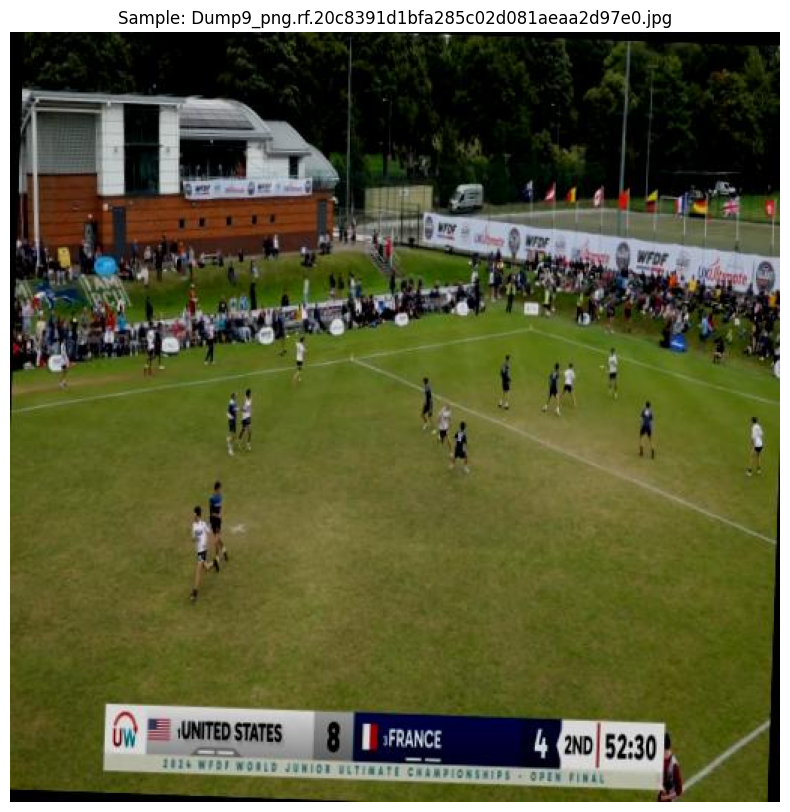

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

image_dir = os.path.join(dataset.location, "train/images")
random_image = random.choice(os.listdir(image_dir))
img_path = os.path.join(image_dir, random_image)

img = mpimg.imread(img_path)
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.title(f"Sample: {random_image}")
plt.axis('off')
plt.show()

**DATA SPLIT AND TRAIN**

In [ ]:
import os, shutil, random, yaml

src_images = '/content/Frisbee-2/train/images'
src_labels = '/content/Frisbee-2/train/labels'
base = '/content/Frisbee-2'

label_stems = {f.rsplit('.', 1)[0] for f in os.listdir(src_labels) if f.endswith('.txt')}

images = []
for f in os.listdir(src_images):
    if f.endswith(('.jpg', '.png', '.jpeg')):
        stem = f.rsplit('.', 1)[0]
        if stem in label_stems:
            images.append(f)

print(f"Matched images with labels: {len(images)}")

random.seed(42)
random.shuffle(images)

n = len(images)
train_end = int(n * 0.7)
valid_end = int(n * 0.9)

splits = {
    'train': images[:train_end],
    'valid': images[train_end:valid_end],
    'test':  images[valid_end:]
}

print(f"Train: {len(splits['train'])} | Valid: {len(splits['valid'])} | Test: {len(splits['test'])}")

for split, files in splits.items():
    for folder in ['images', 'labels']:
        os.makedirs(os.path.join(base, f'{split}_new', folder), exist_ok=True)
    for img_file in files:
        lbl_file = img_file.rsplit('.', 1)[0] + '.txt'
        shutil.copy(os.path.join(src_images, img_file),
                    os.path.join(base, f'{split}_new', 'images', img_file))
        shutil.copy(os.path.join(src_labels, lbl_file),
                    os.path.join(base, f'{split}_new', 'labels', lbl_file))

for split in ['train', 'valid', 'test']:
    old = os.path.join(base, split)
    new = os.path.join(base, f'{split}_new')
    if os.path.exists(old):
        shutil.rmtree(old)
    os.rename(new, old)

print("Split done!")

with open(os.path.join(base, 'data.yaml')) as f:
    data = yaml.safe_load(f)

data['train'] = f'{base}/train/images'
data['val']   = f'{base}/valid/images'
data['test']  = f'{base}/test/images'

with open(os.path.join(base, 'data.yaml'), 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print("Yaml updated! Ready to train.")

Matched images with labels: 454
Train: 317 | Valid: 91 | Test: 46
Split done!
Yaml updated! Ready to train.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data='/content/Frisbee-2/data.yaml',
    epochs=50,
    imgsz=640,
    plots=True,
    project='/content/drive/MyDrive/frisbee_model',
    name='run1'
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Frisbee-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7af914361400>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

**SAVING WEIGHTS, DISPLAYING SAMPLE BOUNDING BOXES, AND ACCURACY**

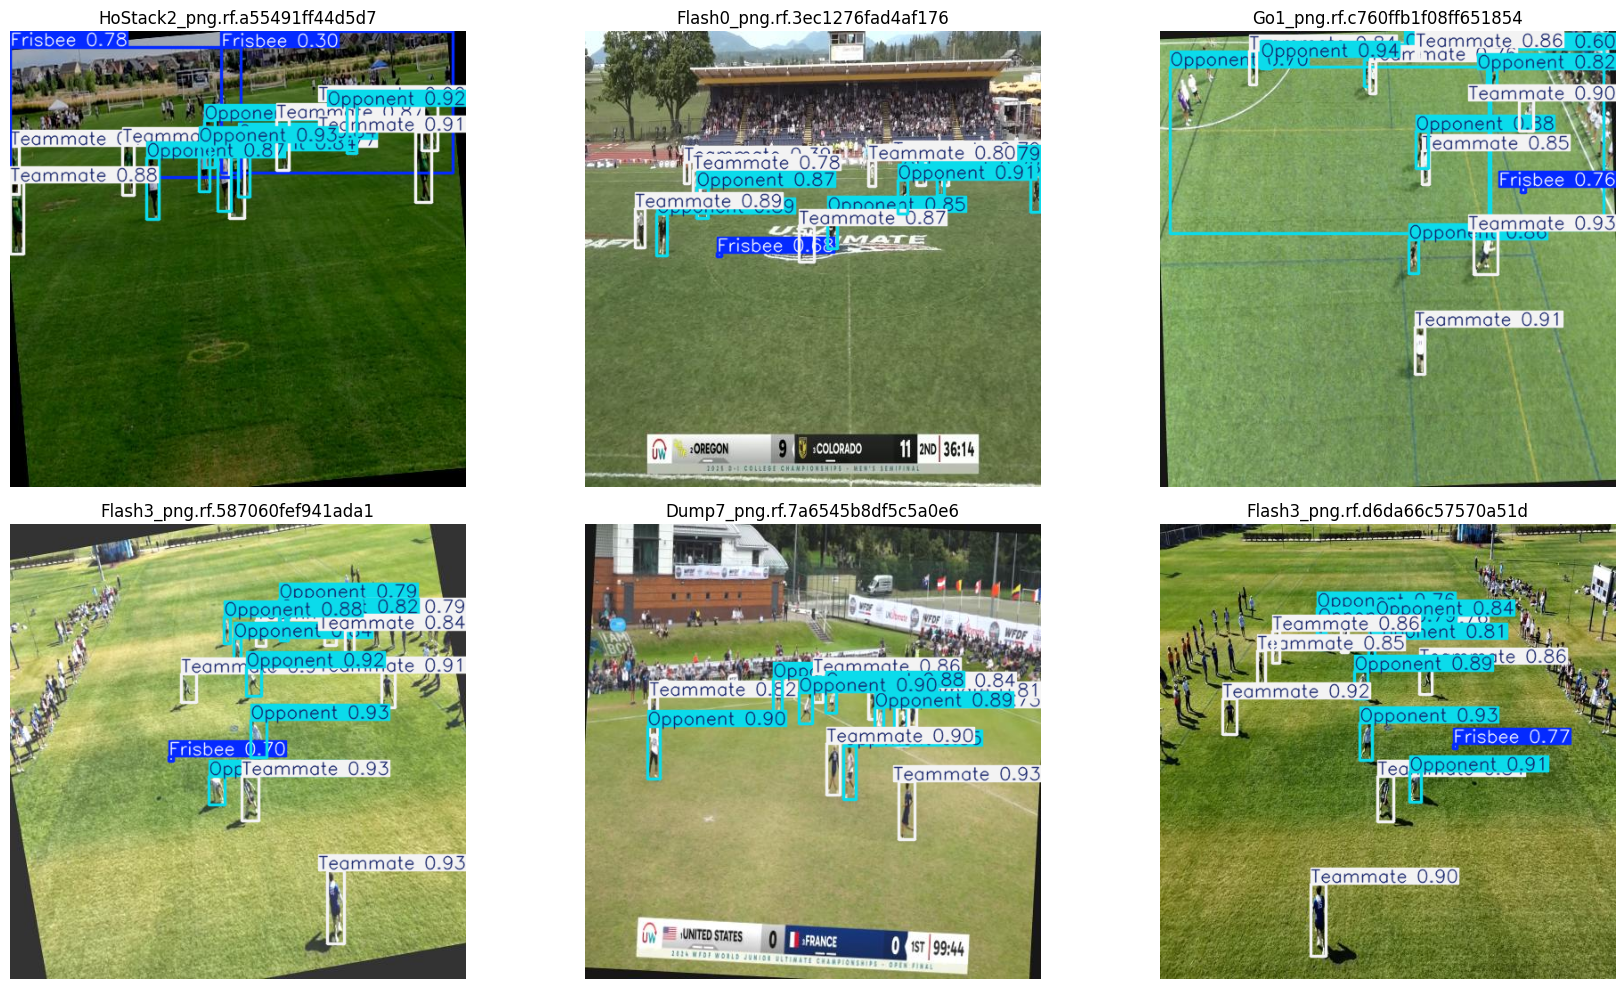

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2, os, random

model = YOLO('/content/drive/MyDrive/frisbee_model/run1/weights/best.pt')

val_images = os.listdir('/content/Frisbee-2/valid/images')
random.shuffle(val_images)
samples = val_images[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, img_file in enumerate(samples):
    img_path = f'/content/Frisbee-2/valid/images/{img_file}'
    results = model.predict(img_path, conf=0.3, verbose=False)

    annotated = results[0].plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    axes[i].imshow(annotated)
    axes[i].set_title(img_file[:30])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Validation set metrics
val_results = model.val(
    data='/content/Frisbee-2/data.yaml',
    split='val',
    plots=True,
    save_dir='/content/drive/MyDrive/frisbee_model/run1/val_eval'
)

# Test set metrics
test_results = model.val(
    data='/content/Frisbee-2/data.yaml',
    split='test',
    plots=True,
    save_dir='/content/drive/MyDrive/frisbee_model/run1/test_eval'
)

print(f"Val  mAP50: {val_results.box.map50:.3f}")
print(f"Test mAP50: {test_results.box.map50:.3f}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1478.8±434.9 MB/s, size: 47.3 KB)
val: Scanning /content/Frisbee-2/valid/labels... 91 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 1.2Kit/s 0.1s
val: New cache created: /content/Frisbee-2/valid/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1253, len(boxes) = 1296. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.1it/s 5.5s
                   all         91       1296      0.869      0.906      0.903      0.665
               Frisbee         91         91      0.731       0.78       0.73      0.397
              Opponent         91        600      0.948      0.974    

**DATA CLEANUP AND DOT MAP SCRIPT**

In [ ]:
import os, re

for img_dir in [
    '/content/Frisbee-2/train/images',
    '/content/Frisbee-2/valid/images',
    '/content/Frisbee-2/test/images'
]:
    if not os.path.exists(img_dir):
        continue
    for f in os.listdir(img_dir):
        if f.lower().startswith('ho') and not f.lower().startswith('hostack'):
            old_path = os.path.join(img_dir, f)
            new_name = 'HoStack' + f[2:]
            os.rename(old_path, os.path.join(img_dir, new_name))
            print(f"Renamed: {f} → {new_name}")

print("Done!")

Renamed: Ho1_png.rf.1cee38fc5ff3a2ab748a162db3e04f47.jpg → HoStack1_png.rf.1cee38fc5ff3a2ab748a162db3e04f47.jpg
Renamed: Ho1_png.rf.fb2345289c4b437fc1129b30c00bcc9e.jpg → HoStack1_png.rf.fb2345289c4b437fc1129b30c00bcc9e.jpg
Renamed: Ho1_png.rf.9fa8ffc01763f8c085d669e6f3fa3144.jpg → HoStack1_png.rf.9fa8ffc01763f8c085d669e6f3fa3144.jpg
Renamed: Ho1_png.rf.fe1b4c15bd8eccc2b582c3195c738695.jpg → HoStack1_png.rf.fe1b4c15bd8eccc2b582c3195c738695.jpg
Renamed: Ho1_png.rf.fede12ea4ff0a42bfe30b57d9954cb8b.jpg → HoStack1_png.rf.fede12ea4ff0a42bfe30b57d9954cb8b.jpg
Renamed: Ho1_png.rf.96f64df6c48355d9b8a4786cdbbd526a.jpg → HoStack1_png.rf.96f64df6c48355d9b8a4786cdbbd526a.jpg
Renamed: Ho1_png.rf.63ac7f8b4e71600f2ab457cff9c742ba.jpg → HoStack1_png.rf.63ac7f8b4e71600f2ab457cff9c742ba.jpg
Renamed: Ho1_png.rf.0f38ec2c181c49cbbc2a44ac05e8a9d3.jpg → HoStack1_png.rf.0f38ec2c181c49cbbc2a44ac05e8a9d3.jpg
Done!


In [ ]:
import shutil
shutil.rmtree('/content/drive/MyDrive/frisbee_dotmaps')
print("Cleared old dot maps")

Cleared old dot maps


Processing and saving all dot maps...
All dot maps saved to /content/drive/MyDrive/frisbee_dotmaps


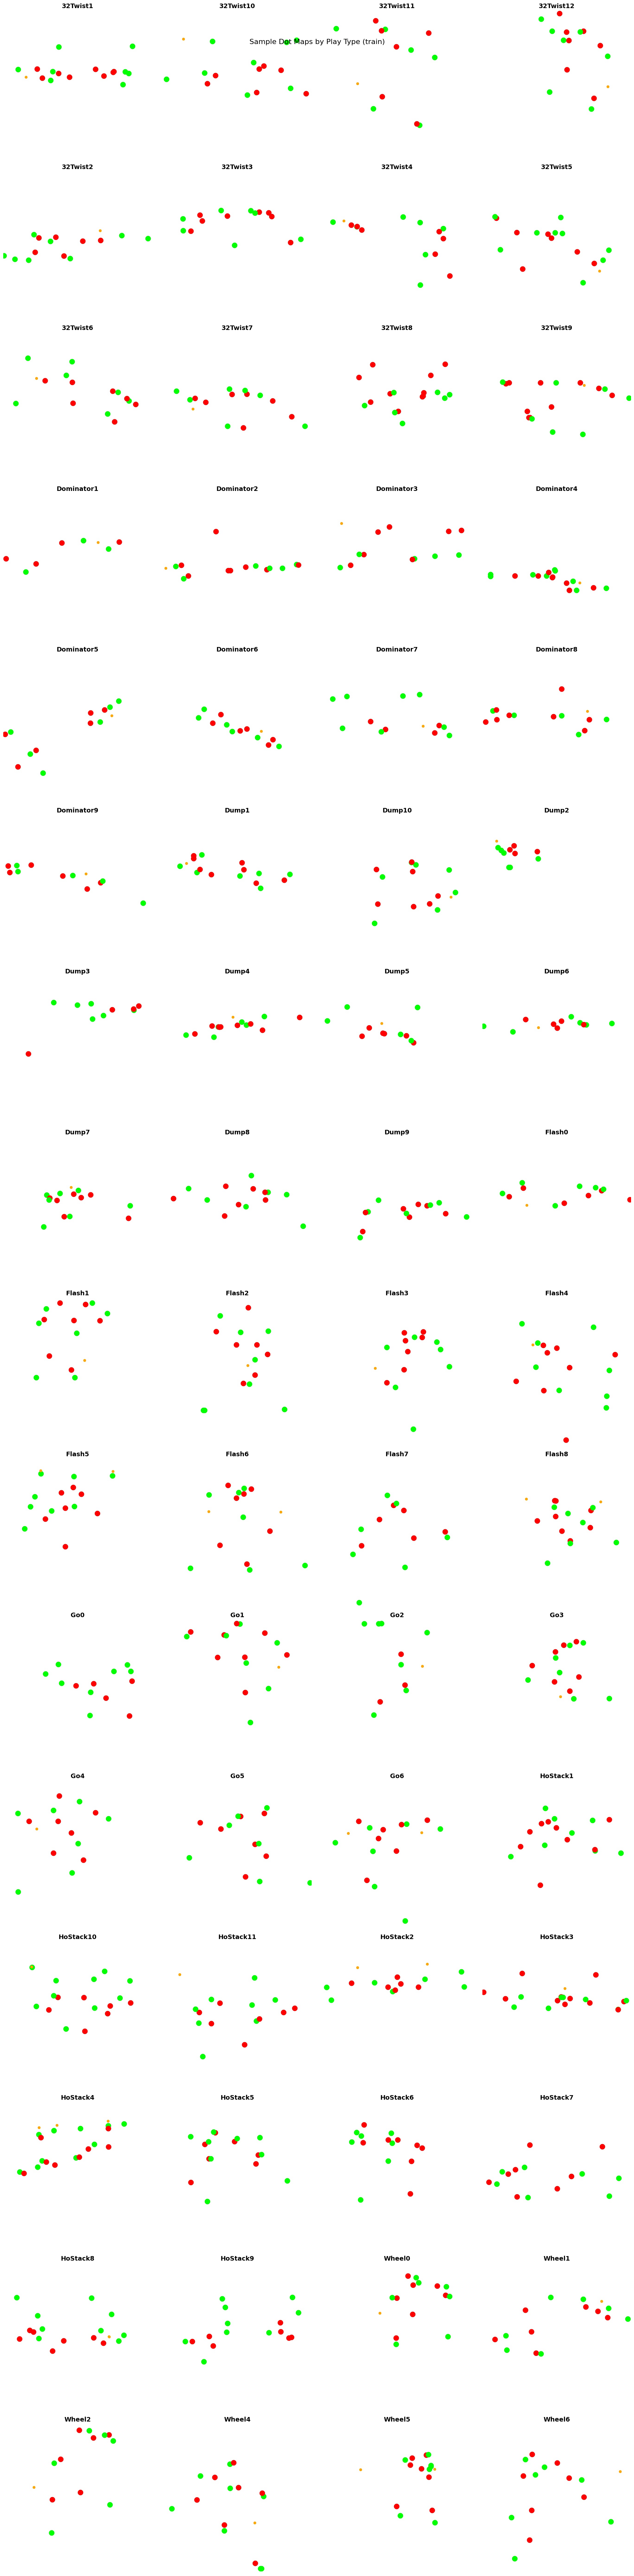

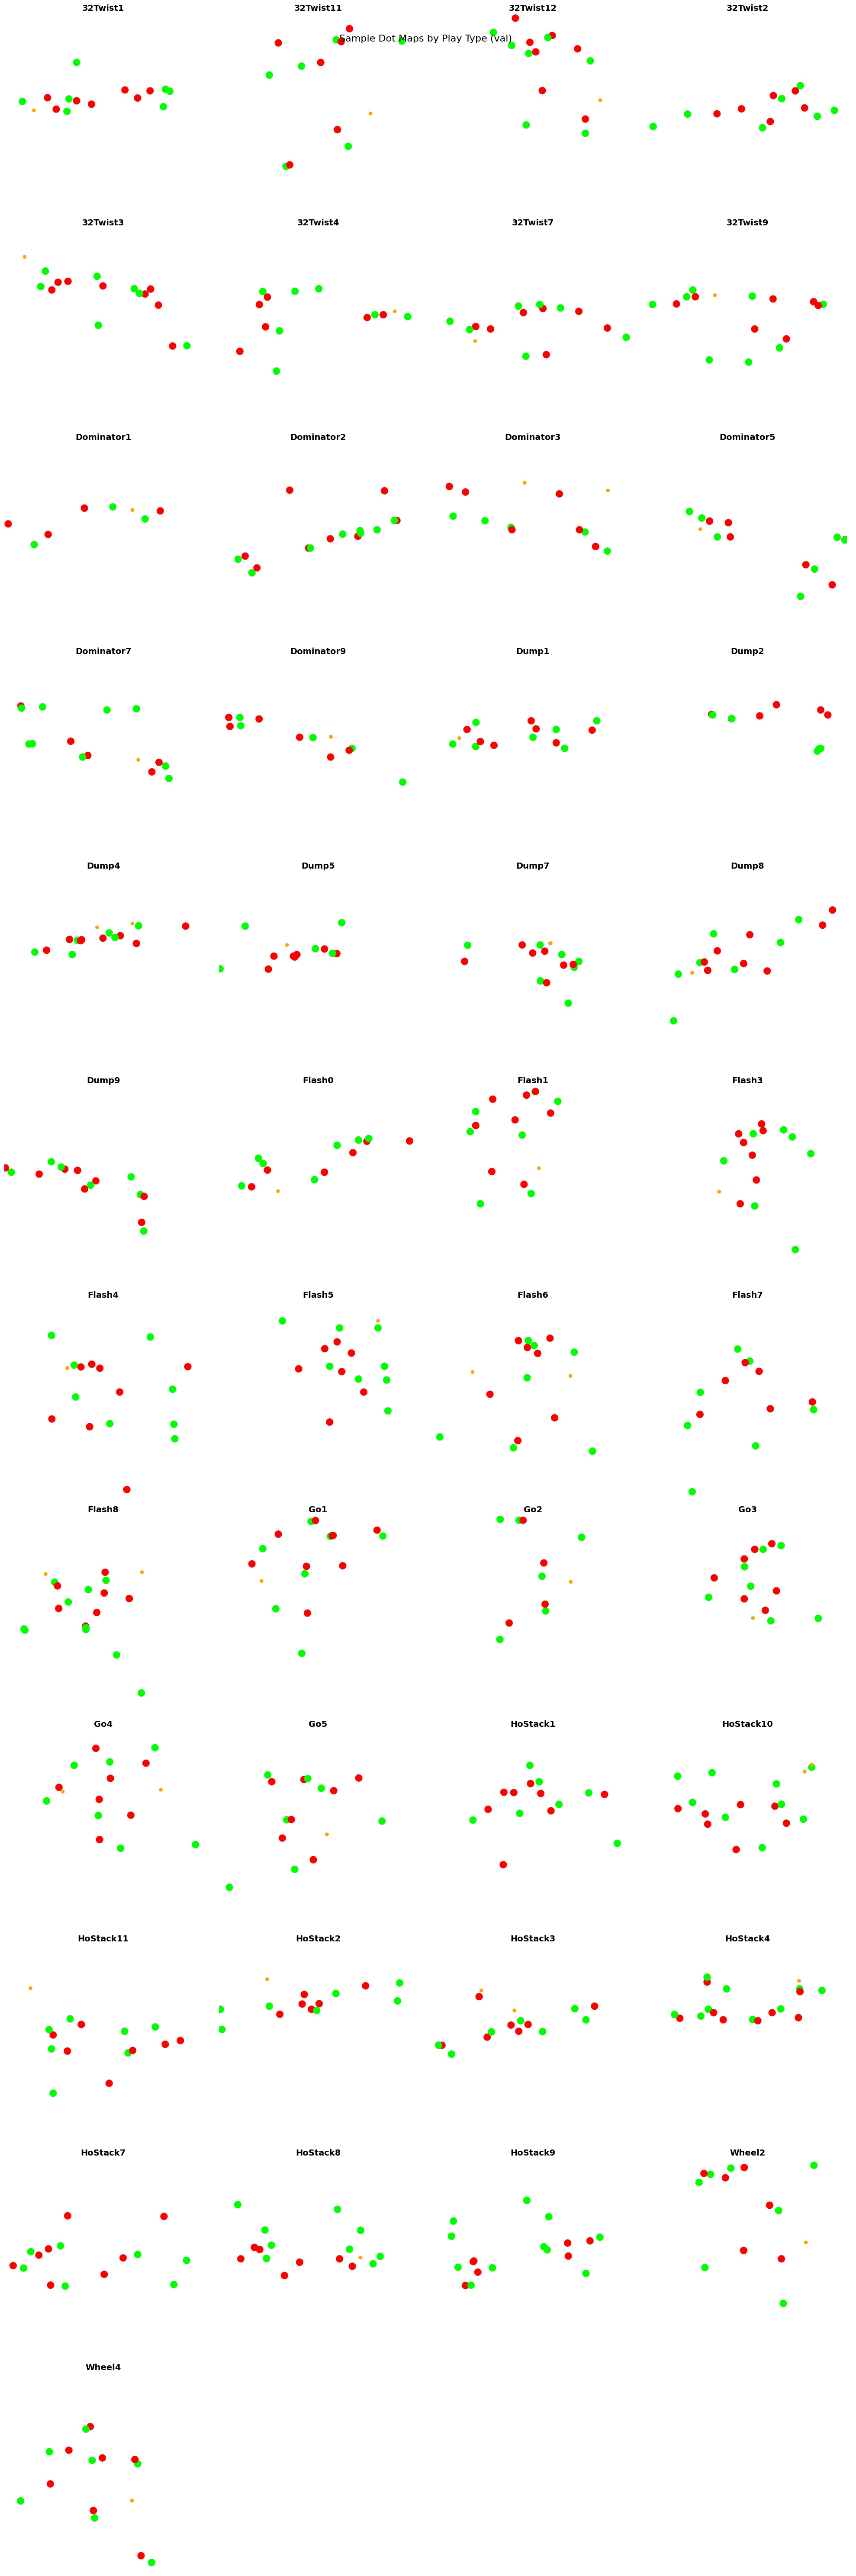

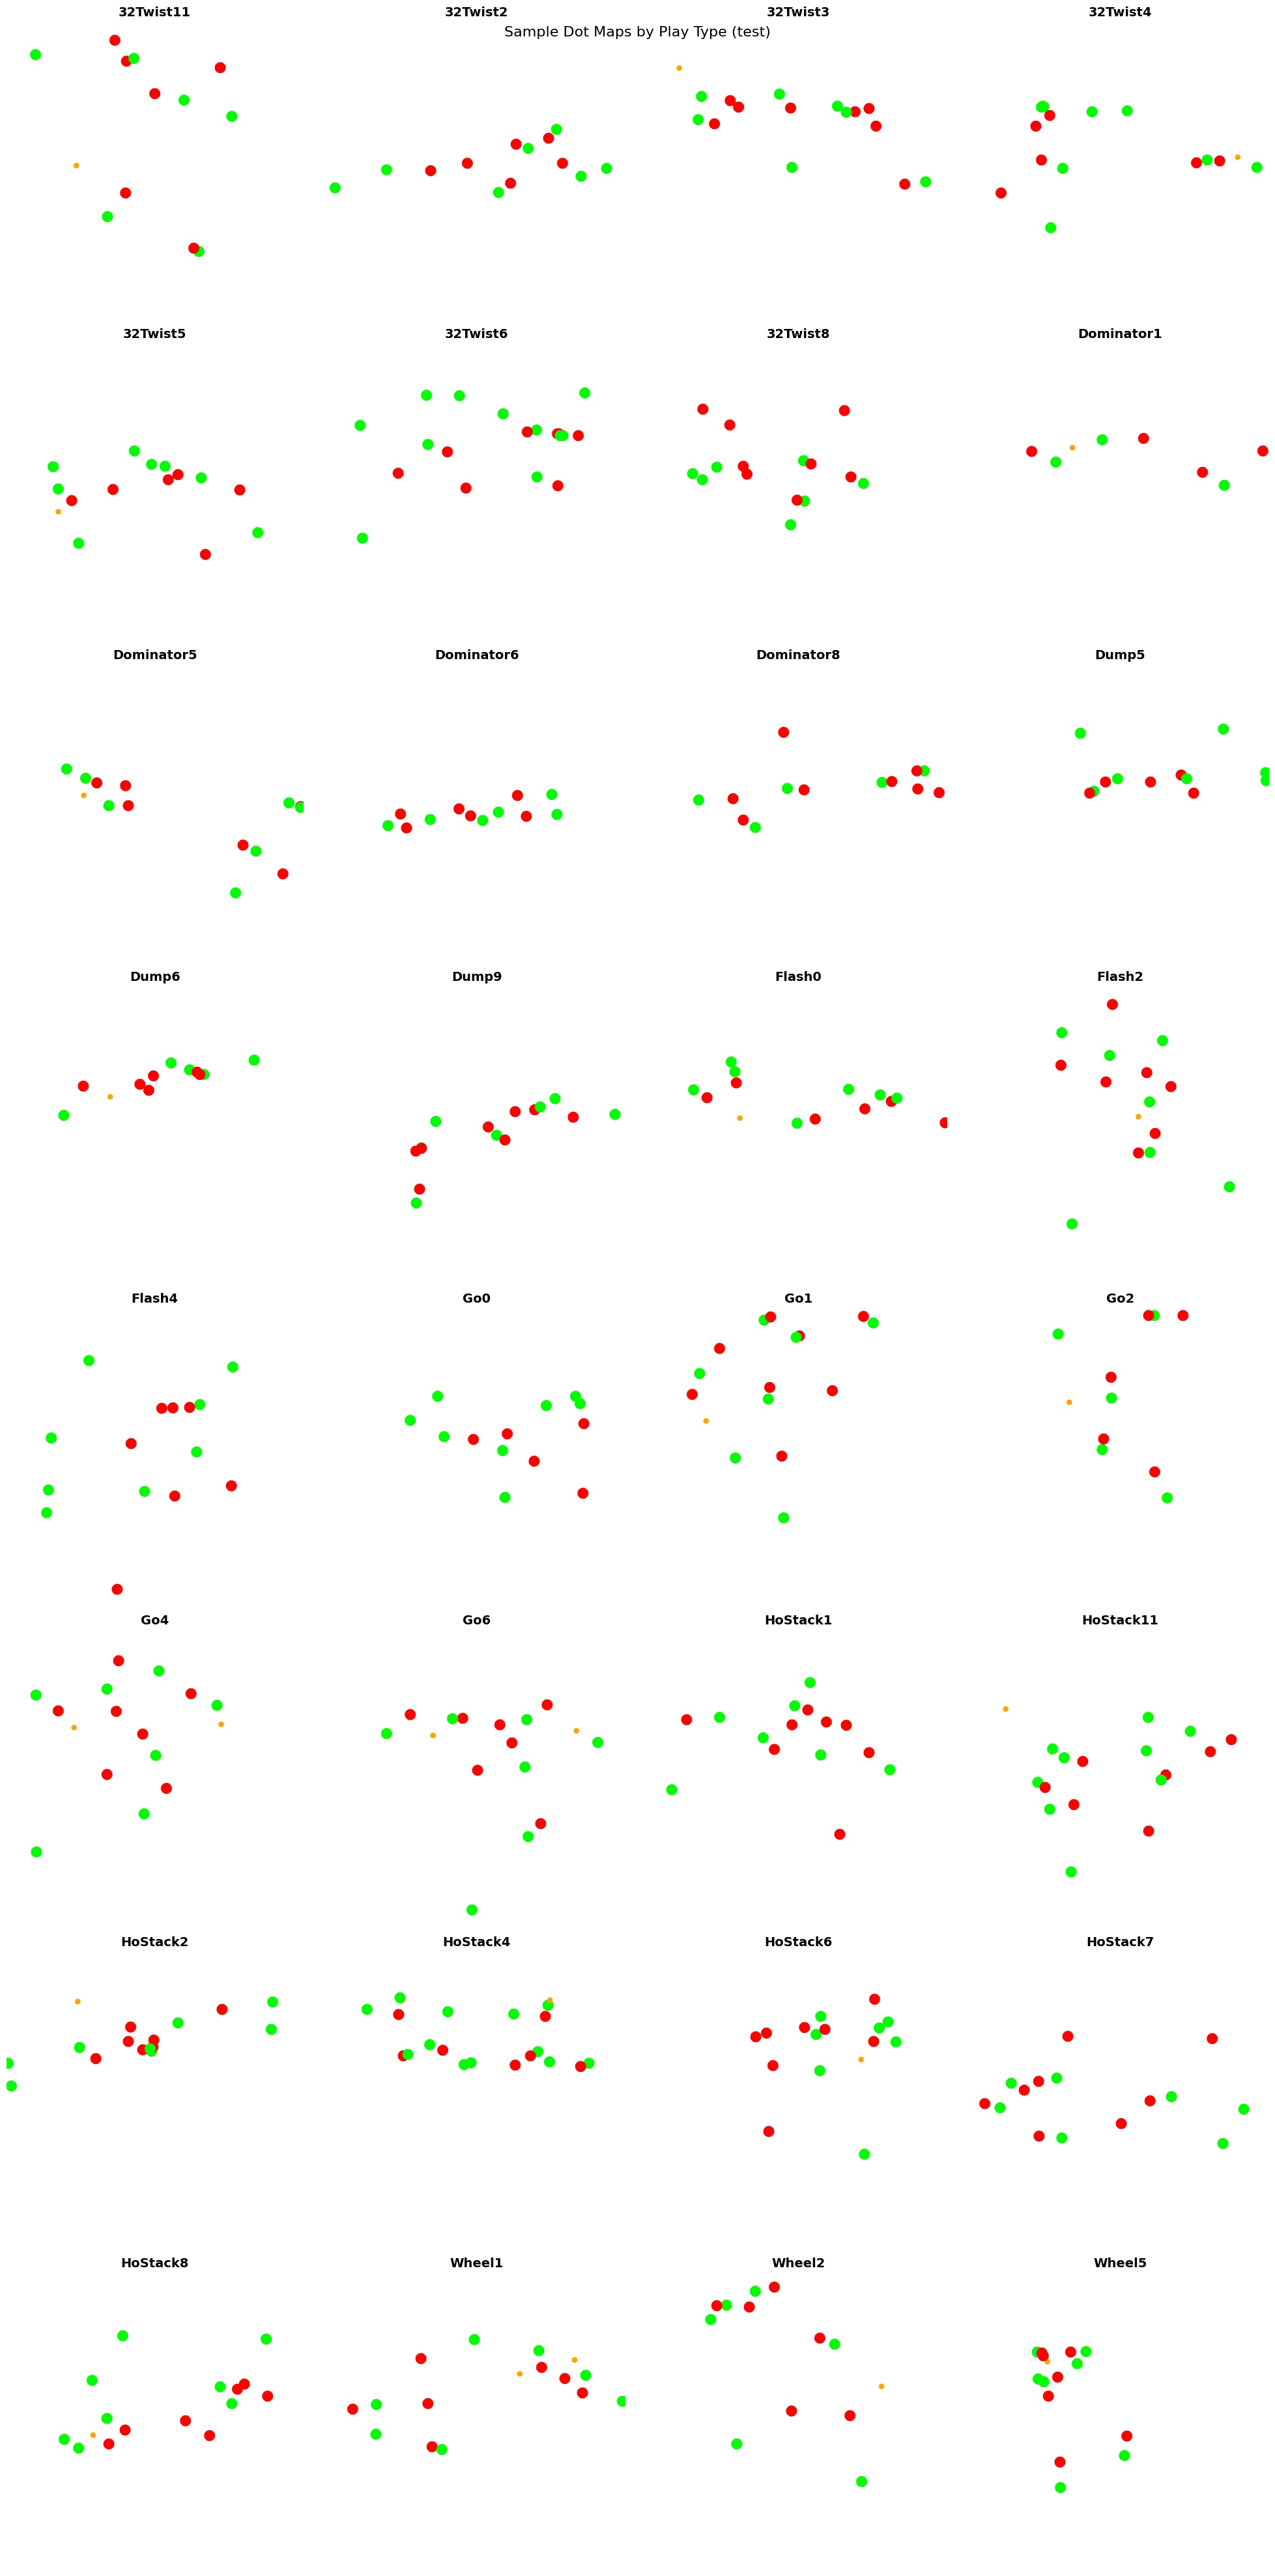

In [ ]:
import os, cv2, re, random, math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

MODEL_PATH = '/content/drive/MyDrive/frisbee_model/run1/weights/best.pt'
OUTPUT_BASE = Path('/content/drive/MyDrive/frisbee_dotmaps')
SPLITS = {
    "train": "/content/Frisbee-2/train/images",
    "val":   "/content/Frisbee-2/valid/images",
    "test":  "/content/Frisbee-2/test/images"
}
COLORS = {0: (0, 165, 255), 1: (0, 0, 255), 2: (0, 255, 0)}
RADII = {0: 6, 1: 12, 2: 12}

model = YOLO(MODEL_PATH)

RENAME_MAP = {'Ho': 'HoStack'}

def clean_label(filename):
    stem = filename.rsplit('.', 1)[0]
    label = re.sub(r'(_png\.rf\..*|\d+)$', '', stem, flags=re.IGNORECASE)
    return RENAME_MAP.get(label, label)

def create_dotmap(img_path, model, size=(640, 640)):
    res = model.predict(img_path, conf=0.3, verbose=False)[0]
    m = np.ones((size[1], size[0], 3), dtype=np.uint8) * 255
    sh = res.orig_shape
    for box in res.boxes:
        cls, (cx, cy, _, _) = int(box.cls), box.xywh[0].tolist()
        px, py = int(cx * (size[0]/sh[1])), int(cy * (size[1]/sh[0]))
        if cls in COLORS:
            cv2.circle(m, (px, py), RADII[cls], COLORS[cls], -1)
    return m

print("Processing and saving all dot maps...")

for split, img_dir in SPLITS.items():
    img_path_obj = Path(img_dir)
    if not img_path_obj.exists():
        continue
    for img_file in img_path_obj.glob('*.[jJ][pP][gG]'):
        play = clean_label(img_file.name)
        out_dir = OUTPUT_BASE / split / play
        out_dir.mkdir(parents=True, exist_ok=True)
        dot_map = create_dotmap(str(img_file), model)
        cv2.imwrite(str(out_dir / img_file.name), dot_map)

print(f"All dot maps saved to {OUTPUT_BASE}")

for split in SPLITS.keys():
    dotmap_base = str(OUTPUT_BASE / split)
    if not os.path.exists(dotmap_base):
        continue
    labels = sorted([d for d in os.listdir(dotmap_base) if os.path.isdir(os.path.join(dotmap_base, d))])
    if not labels:
        continue
    cols = 4
    rows = math.ceil(len(labels) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = np.array(axes).flatten()
    i = 0
    for label in labels:
        label_dir = os.path.join(dotmap_base, label)
        files = [f for f in os.listdir(label_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        if not files:
            continue
        sample = random.choice(files)
        img = cv2.imread(os.path.join(label_dir, sample))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(label, fontsize=14, fontweight='bold')
        axes[i].axis('off')
        i += 1
    for j in range(i, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f'Sample Dot Maps by Play Type ({split})', fontsize=16)
    plt.tight_layout()
    plt.show()

**MERGING DATA INTO 7 CLASSES, FURTHER AUGMENTATION BEFORE TRAINING CNNs**

In [ ]:
import os, re, shutil
from pathlib import Path

for split_imgs in [
    '/content/Frisbee-2/train/images',
    '/content/Frisbee-2/valid/images',
    '/content/Frisbee-2/test/images'
]:
    if not os.path.exists(split_imgs):
        continue
    for f in os.listdir(split_imgs):
        if f.lower().startswith('ho') and not f.lower().startswith('hostack'):
            old_path = os.path.join(split_imgs, f)
            new_name = 'HoStack' + f[2:]
            os.rename(old_path, os.path.join(split_imgs, new_name))
            print(f"Renamed: {f} → {new_name}")

dotmap_base = Path('/content/drive/MyDrive/frisbee_dotmaps')

RENAME_MAP = {'Ho': 'HoStack'}

def get_base_class(folder_name):
    if folder_name in RENAME_MAP:
        return RENAME_MAP[folder_name]
    return re.sub(r'\d+$', '', folder_name).strip()

for split in ['train', 'val', 'test']:
    split_dir = dotmap_base / split
    if not split_dir.exists():
        continue
    for folder in list(split_dir.iterdir()):
        if not folder.is_dir():
            continue
        base = get_base_class(folder.name)
        if base != folder.name:
            target = split_dir / base
            target.mkdir(exist_ok=True)
            for f in folder.glob('*'):
                shutil.move(str(f), str(target / f.name))
            shutil.rmtree(str(folder))
            print(f"Merged {folder.name} → {base}")

print("\nDone! Final class folders:")
for split in ['train', 'val', 'test']:
    split_dir = dotmap_base / split
    if split_dir.exists():
        dirs = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
        print(f"  {split}: {dirs}")

Merged Dominator5 → Dominator
Merged HoStack9 → HoStack
Merged Dump6 → Dump
Merged Go5 → Go
Merged Flash1 → Flash
Merged HoStack5 → HoStack
Merged Flash7 → Flash
Merged HoStack8 → HoStack
Merged 32Twist5 → 32Twist
Merged Dominator8 → Dominator
Merged Wheel6 → Wheel
Merged Wheel1 → Wheel
Merged HoStack2 → HoStack
Merged HoStack3 → HoStack
Merged Go1 → Go
Merged 32Twist4 → 32Twist
Merged Flash8 → Flash
Merged 32Twist11 → 32Twist
Merged Dominator4 → Dominator
Merged 32Twist8 → 32Twist
Merged Dump8 → Dump
Merged Dump10 → Dump
Merged Dominator1 → Dominator
Merged Dump1 → Dump
Merged Dump4 → Dump
Merged Wheel2 → Wheel
Merged HoStack1 → HoStack
Merged Go4 → Go
Merged 32Twist10 → 32Twist
Merged Dump5 → Dump
Merged Dominator6 → Dominator
Merged Go2 → Go
Merged Go6 → Go
Merged Flash5 → Flash
Merged Wheel0 → Wheel
Merged HoStack6 → HoStack
Merged Go0 → Go
Merged HoStack10 → HoStack
Merged Wheel4 → Wheel
Merged Flash0 → Flash
Merged Go3 → Go
Merged Wheel5 → Wheel
Merged Dump3 → Dump
Merged 32Twist

In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = '/content/drive/MyDrive/frisbee_dotmaps/train'
val_dir   = '/content/drive/MyDrive/frisbee_dotmaps/val'
test_dir  = '/content/drive/MyDrive/frisbee_dotmaps/test'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)

val_dataset = datasets.ImageFolder(val_dir, transform=transform) if os.path.exists(val_dir) else None
test_dataset = datasets.ImageFolder(test_dir, transform=transform) if os.path.exists(test_dir) else None

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False) if val_dataset else None
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) if test_dataset else None

print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))
print("Train size:", len(train_dataset))
if val_dataset:
    print("Val size:", len(val_dataset))
if test_dataset:
    print("Test size:", len(test_dataset))

Classes: ['32Twist', 'Dominator', 'Dump', 'Flash', 'Go', 'HoStack', 'Wheel']
Number of classes: 7
Train size: 317
Val size: 91
Test size: 46


In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset.transform = train_transforms
val_dataset.transform = val_transforms
test_dataset.transform = val_transforms

**RUN THE NEXT TWO CELLS FOR RESNET MODEL**

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_dataset.classes)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

num_classes = len(train_dataset.classes)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam([
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': 1e-5},
    {'params': model.fc.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

epochs = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 7

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(model, val_loader)

    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"Best model saved (val loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

model.load_state_dict(torch.load('best_model.pt'))
print("Best model reloaded")

Epoch 1/30 | Train Loss: 2.0542 | Train Acc: 0.1483 | Val Loss: 1.9799 | Val Acc: 0.1868
Best model saved (val loss: 1.9799)
Epoch 2/30 | Train Loss: 1.8998 | Train Acc: 0.2366 | Val Loss: 1.7765 | Val Acc: 0.1978
Best model saved (val loss: 1.7765)
Epoch 3/30 | Train Loss: 1.7940 | Train Acc: 0.2713 | Val Loss: 1.7301 | Val Acc: 0.2967
Best model saved (val loss: 1.7301)
Epoch 4/30 | Train Loss: 1.6509 | Train Acc: 0.3912 | Val Loss: 1.6344 | Val Acc: 0.3736
Best model saved (val loss: 1.6344)
Epoch 5/30 | Train Loss: 1.5683 | Train Acc: 0.4164 | Val Loss: 1.5607 | Val Acc: 0.3846
Best model saved (val loss: 1.5607)
Epoch 6/30 | Train Loss: 1.5077 | Train Acc: 0.4479 | Val Loss: 1.4946 | Val Acc: 0.4396
Best model saved (val loss: 1.4946)
Epoch 7/30 | Train Loss: 1.4266 | Train Acc: 0.4574 | Val Loss: 1.4675 | Val Acc: 0.4835
Best model saved (val loss: 1.4675)
Epoch 8/30 | Train Loss: 1.3951 | Train Acc: 0.4953 | Val Loss: 1.3978 | Val Acc: 0.5495
Best model saved (val loss: 1.3978)


**RUN THE NEXT TWO CELLS FOR THE SELF-BUILT CNN**

In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_dataset.classes)

class FrisbeeNet(nn.Module):
    def __init__(self, num_classes):
        super(FrisbeeNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model2 = FrisbeeNet(num_classes).to(device)
print(model2)

FrisbeeNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

optimizer = optim.Adam(model2.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model2.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model2(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

epochs = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 5

for epoch in range(epochs):
    model2.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model2(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(model2, val_loader)

    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model2.state_dict(), 'best_model2.pt')
        print(f"Best model saved (val loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

model2.load_state_dict(torch.load('best_model2.pt'))
print("Best model reloaded")

Epoch 1/30 | Train Loss: 2.1032 | Train Acc: 0.1861 | Val Loss: 1.9470 | Val Acc: 0.1209
Best model saved (val loss: 1.9470)
Epoch 2/30 | Train Loss: 2.0790 | Train Acc: 0.1767 | Val Loss: 1.8982 | Val Acc: 0.2967
Best model saved (val loss: 1.8982)
Epoch 3/30 | Train Loss: 1.9418 | Train Acc: 0.2334 | Val Loss: 1.8079 | Val Acc: 0.3626
Best model saved (val loss: 1.8079)
Epoch 4/30 | Train Loss: 1.8567 | Train Acc: 0.2271 | Val Loss: 1.7681 | Val Acc: 0.3297
Best model saved (val loss: 1.7681)
Epoch 5/30 | Train Loss: 1.8637 | Train Acc: 0.2492 | Val Loss: 1.6832 | Val Acc: 0.3516
Best model saved (val loss: 1.6832)
Epoch 6/30 | Train Loss: 1.8141 | Train Acc: 0.2744 | Val Loss: 1.6249 | Val Acc: 0.4615
Best model saved (val loss: 1.6249)
Epoch 7/30 | Train Loss: 1.7844 | Train Acc: 0.2776 | Val Loss: 1.6070 | Val Acc: 0.5055
Best model saved (val loss: 1.6070)
Epoch 8/30 | Train Loss: 1.7912 | Train Acc: 0.2461 | Val Loss: 1.6172 | Val Acc: 0.4725
No improvement (1/5)
Epoch 9/30 | Tr

**RUN THE NEXT CELL FOR THE EFFICIENTNET-B0**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_dataset.classes)

model3 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)


model3.classifier[1] = nn.Linear(model3.classifier[1].in_features, num_classes)

model3 = model3.to(device)

for param in model3.parameters():
    param.requires_grad = True

optimizer3 = optim.Adam([
    {'params': [p for n, p in model3.named_parameters() if 'classifier' not in n], 'lr': 1e-5},
    {'params': model3.classifier.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

scheduler3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer3,
    mode='min',
    patience=3,
    factor=0.5
)

criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

epochs = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 7

for epoch in range(epochs):
    model3.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer3.zero_grad()

        outputs = model3(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model3.parameters(), max_norm=1.0)
        optimizer3.step()

        running_loss += loss.item() * imgs.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    val_loss, val_acc = evaluate(model3, val_loader)

    scheduler3.step(val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model3.state_dict(), "best_model3_efficientnet_b0.pt")
        print(f"Best EfficientNet-B0 model saved, val loss: {val_loss:.4f}")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

model3.load_state_dict(torch.load("best_model3_efficientnet_b0.pt", map_location=device))
print("Best EfficientNet-B0 model reloaded")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 129MB/s]


Epoch 1/30 | Train Loss: 1.9403 | Train Acc: 0.1861 | Val Loss: 1.9308 | Val Acc: 0.1758
Best EfficientNet-B0 model saved, val loss: 1.9308
Epoch 2/30 | Train Loss: 1.9287 | Train Acc: 0.1609 | Val Loss: 1.8771 | Val Acc: 0.1868
Best EfficientNet-B0 model saved, val loss: 1.8771
Epoch 3/30 | Train Loss: 1.8644 | Train Acc: 0.2429 | Val Loss: 1.8374 | Val Acc: 0.2198
Best EfficientNet-B0 model saved, val loss: 1.8374
Epoch 4/30 | Train Loss: 1.8456 | Train Acc: 0.2397 | Val Loss: 1.7765 | Val Acc: 0.2527
Best EfficientNet-B0 model saved, val loss: 1.7765
Epoch 5/30 | Train Loss: 1.7749 | Train Acc: 0.3155 | Val Loss: 1.7194 | Val Acc: 0.3297
Best EfficientNet-B0 model saved, val loss: 1.7194
Epoch 6/30 | Train Loss: 1.7858 | Train Acc: 0.2618 | Val Loss: 1.6827 | Val Acc: 0.3297
Best EfficientNet-B0 model saved, val loss: 1.6827
Epoch 7/30 | Train Loss: 1.7101 | Train Acc: 0.3407 | Val Loss: 1.6427 | Val Acc: 0.3736
Best EfficientNet-B0 model saved, val loss: 1.6427
Epoch 8/30 | Train L

**Model Comparison**




In [ ]:
!pip install scikit-learn seaborn

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_model_size_mb(model, filename):
    torch.save(model.state_dict(), filename)
    size_mb = os.path.getsize(filename) / (1024 * 1024)
    return size_mb

def evaluate_comprehensive(model, loader, criterion, device):
    model.eval()

    all_preds = []
    all_labels = []

    total_loss = 0.0
    total = 0

    start_time = time.time()

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            total += labels.size(0)

            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    elapsed_time = time.time() - start_time

    avg_loss = total_loss / total
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    avg_inference_time_ms = (elapsed_time / total) * 1000

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "time_sec": elapsed_time,
        "avg_inference_time_ms": avg_inference_time_ms,
        "labels": all_labels,
        "preds": all_preds
    }


In [ ]:
resnet_results = evaluate_comprehensive(model, test_loader, criterion, device)
cnn_results = evaluate_comprehensive(model2, test_loader, criterion, device)
efficientnet_results = evaluate_comprehensive(model3, test_loader, criterion, device)

comparison_df = pd.DataFrame([
    {
        "Model": "ResNet18 Transfer Learning",
        "Test Loss": resnet_results["loss"],
        "Accuracy": resnet_results["accuracy"],
        "Precision": resnet_results["precision"],
        "Recall": resnet_results["recall"],
        "F1 Score": resnet_results["f1"],
        "Parameters": count_parameters(model),
        "Model Size (MB)": get_model_size_mb(model, "resnet18_model_temp.pt"),
        "Total Eval Time (sec)": resnet_results["time_sec"],
        "Avg Inference Time/Image (ms)": resnet_results["avg_inference_time_ms"]
    },
    {
        "Model": "Self-Made CNN",
        "Test Loss": cnn_results["loss"],
        "Accuracy": cnn_results["accuracy"],
        "Precision": cnn_results["precision"],
        "Recall": cnn_results["recall"],
        "F1 Score": cnn_results["f1"],
        "Parameters": count_parameters(model2),
        "Model Size (MB)": get_model_size_mb(model2, "custom_cnn_model_temp.pt"),
        "Total Eval Time (sec)": cnn_results["time_sec"],
        "Avg Inference Time/Image (ms)": cnn_results["avg_inference_time_ms"]
    },
    {
        "Model": "EfficientNet-B0 Transfer Learning",
        "Test Loss": efficientnet_results["loss"],
        "Accuracy": efficientnet_results["accuracy"],
        "Precision": efficientnet_results["precision"],
        "Recall": efficientnet_results["recall"],
        "F1 Score": efficientnet_results["f1"],
        "Parameters": count_parameters(model3),
        "Model Size (MB)": get_model_size_mb(model3, "efficientnet_b0_model_temp.pt"),
        "Total Eval Time (sec)": efficientnet_results["time_sec"],
        "Avg Inference Time/Image (ms)": efficientnet_results["avg_inference_time_ms"]
    }
])


formatted_df = comparison_df.copy()

for col in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    formatted_df[col] = formatted_df[col].apply(lambda x: f"{x * 100:.2f}%")

formatted_df["Test Loss"] = formatted_df["Test Loss"].apply(lambda x: f"{x:.4f}")
formatted_df["Model Size (MB)"] = formatted_df["Model Size (MB)"].apply(lambda x: f"{x:.2f}")
formatted_df["Avg Inference Time/Image (ms)"] = formatted_df["Avg Inference Time/Image (ms)"].apply(lambda x: f"{x:.2f}")

display(formatted_df)


,Model,Test Loss,Accuracy,Precision,Recall,F1 Score,Parameters,Model Size (MB),Total Eval Time (sec),Avg Inference Time/Image (ms)
0,ResNet18 Transfer Learning,0.4229,91.30%,91.81%,91.30%,91.16%,11180103,42.73,0.582064,12.65
1,Self-Made CNN,0.8804,71.74%,74.25%,71.74%,71.49%,26146567,99.76,0.529952,11.52
2,EfficientNet-B0 Transfer Learning,1.0917,58.70%,64.78%,58.70%,59.11%,4016515,15.61,0.582583,12.66


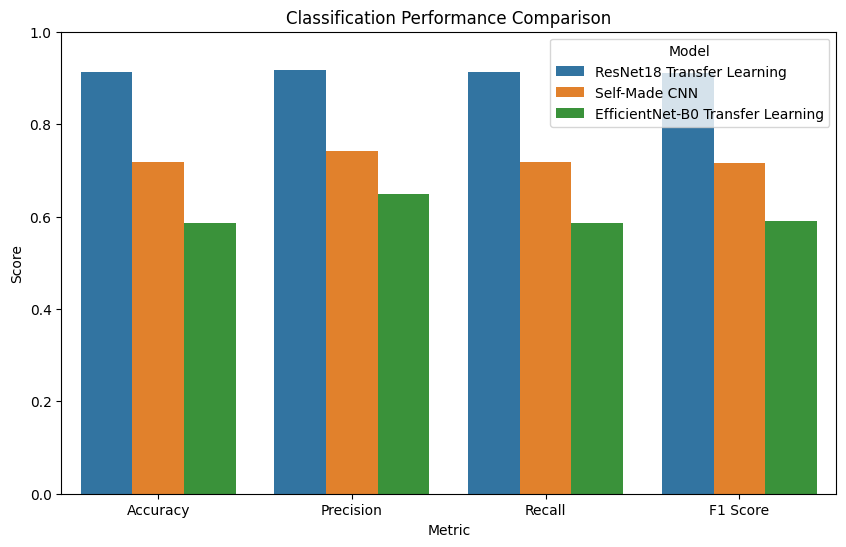

In [ ]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score"]

plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.title("Classification Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.show()


set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


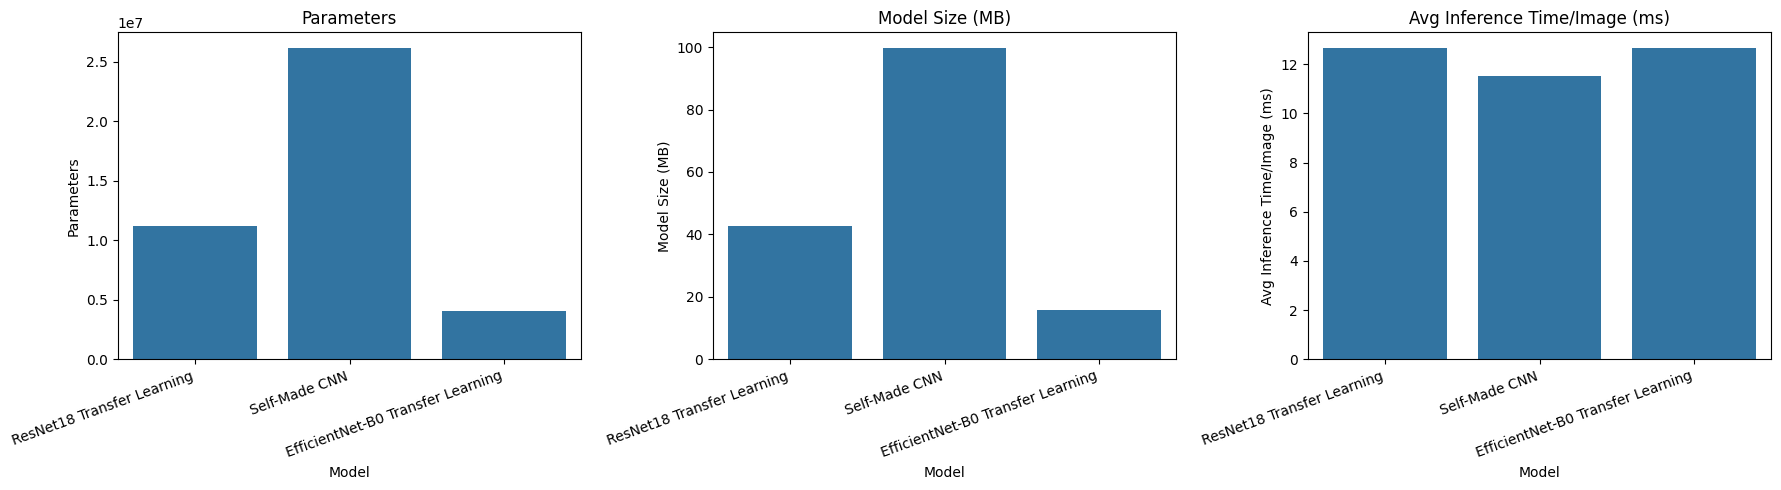

In [ ]:
efficiency_metrics = ["Parameters", "Model Size (MB)", "Avg Inference Time/Image (ms)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, efficiency_metrics):
    sns.barplot(data=comparison_df, x="Model", y=metric, ax=ax)
    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.show()


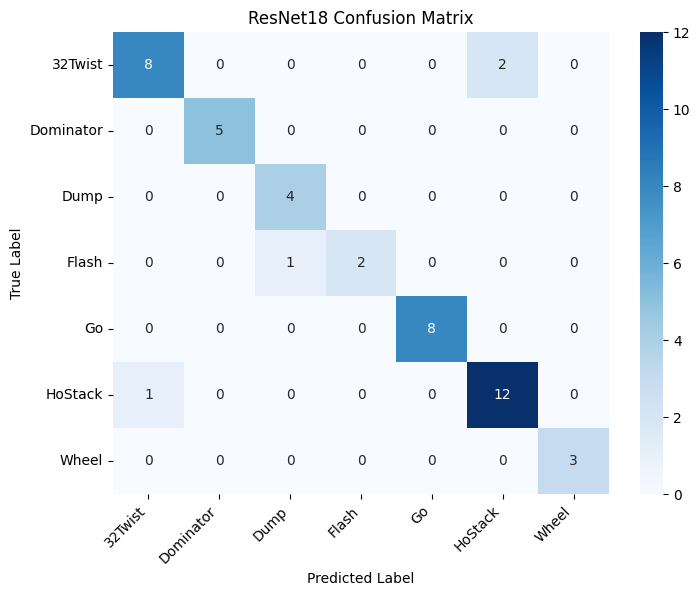

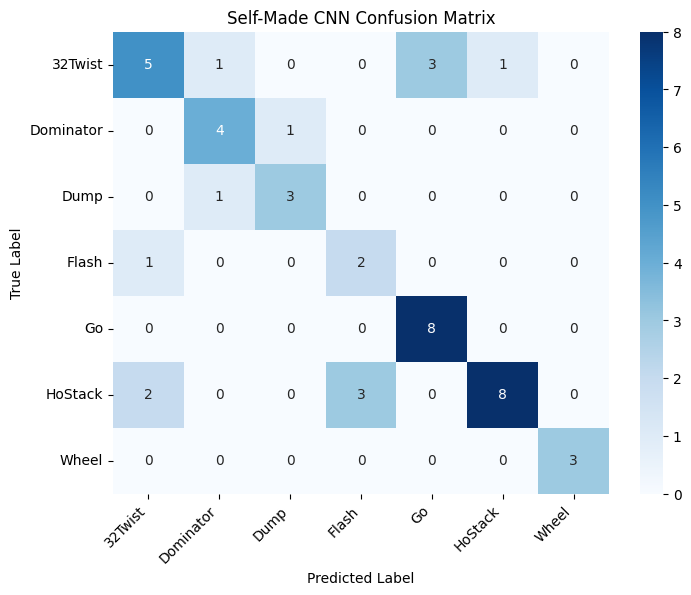

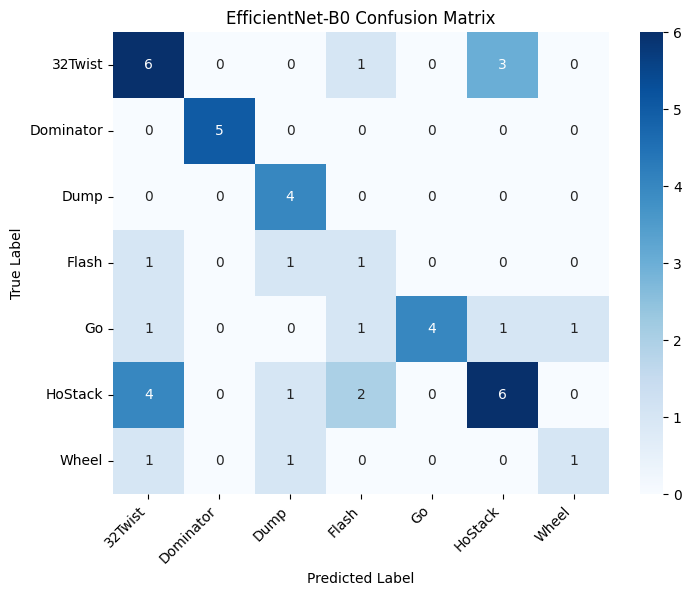

In [ ]:
def plot_confusion_matrix(labels, preds, classes, title):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.show()

plot_confusion_matrix(
    resnet_results["labels"],
    resnet_results["preds"],
    classes,
    "ResNet18 Confusion Matrix"
)

plot_confusion_matrix(
    cnn_results["labels"],
    cnn_results["preds"],
    classes,
    "Self-Made CNN Confusion Matrix"
)

plot_confusion_matrix(
    efficientnet_results["labels"],
    efficientnet_results["preds"],
    classes,
    "EfficientNet-B0 Confusion Matrix"
)




In [ ]:
print("ResNet18 Classification Report")
print(classification_report(
    resnet_results["labels"],
    resnet_results["preds"],
    target_names=classes,
    zero_division=0
))

print("Self-Made CNN Classification Report")
print(classification_report(
    cnn_results["labels"],
    cnn_results["preds"],
    target_names=classes,
    zero_division=0
))

print("EfficientNet-B0 Classification Report")
print(classification_report(
    efficientnet_results["labels"],
    efficientnet_results["preds"],
    target_names=classes,
    zero_division=0
))




ResNet18 Classification Report
              precision    recall  f1-score   support

     32Twist       0.89      0.80      0.84        10
   Dominator       1.00      1.00      1.00         5
        Dump       0.80      1.00      0.89         4
       Flash       1.00      0.67      0.80         3
          Go       1.00      1.00      1.00         8
     HoStack       0.86      0.92      0.89        13
       Wheel       1.00      1.00      1.00         3

    accuracy                           0.91        46
   macro avg       0.94      0.91      0.92        46
weighted avg       0.92      0.91      0.91        46

Self-Made CNN Classification Report
              precision    recall  f1-score   support

     32Twist       0.62      0.50      0.56        10
   Dominator       0.67      0.80      0.73         5
        Dump       0.75      0.75      0.75         4
       Flash       0.40      0.67      0.50         3
          Go       0.73      1.00      0.84         8
     HoStac

**TEST ACCURACY AND SAMPLE DOT MAP CLASSIFICATION (RESNET ONLY)**

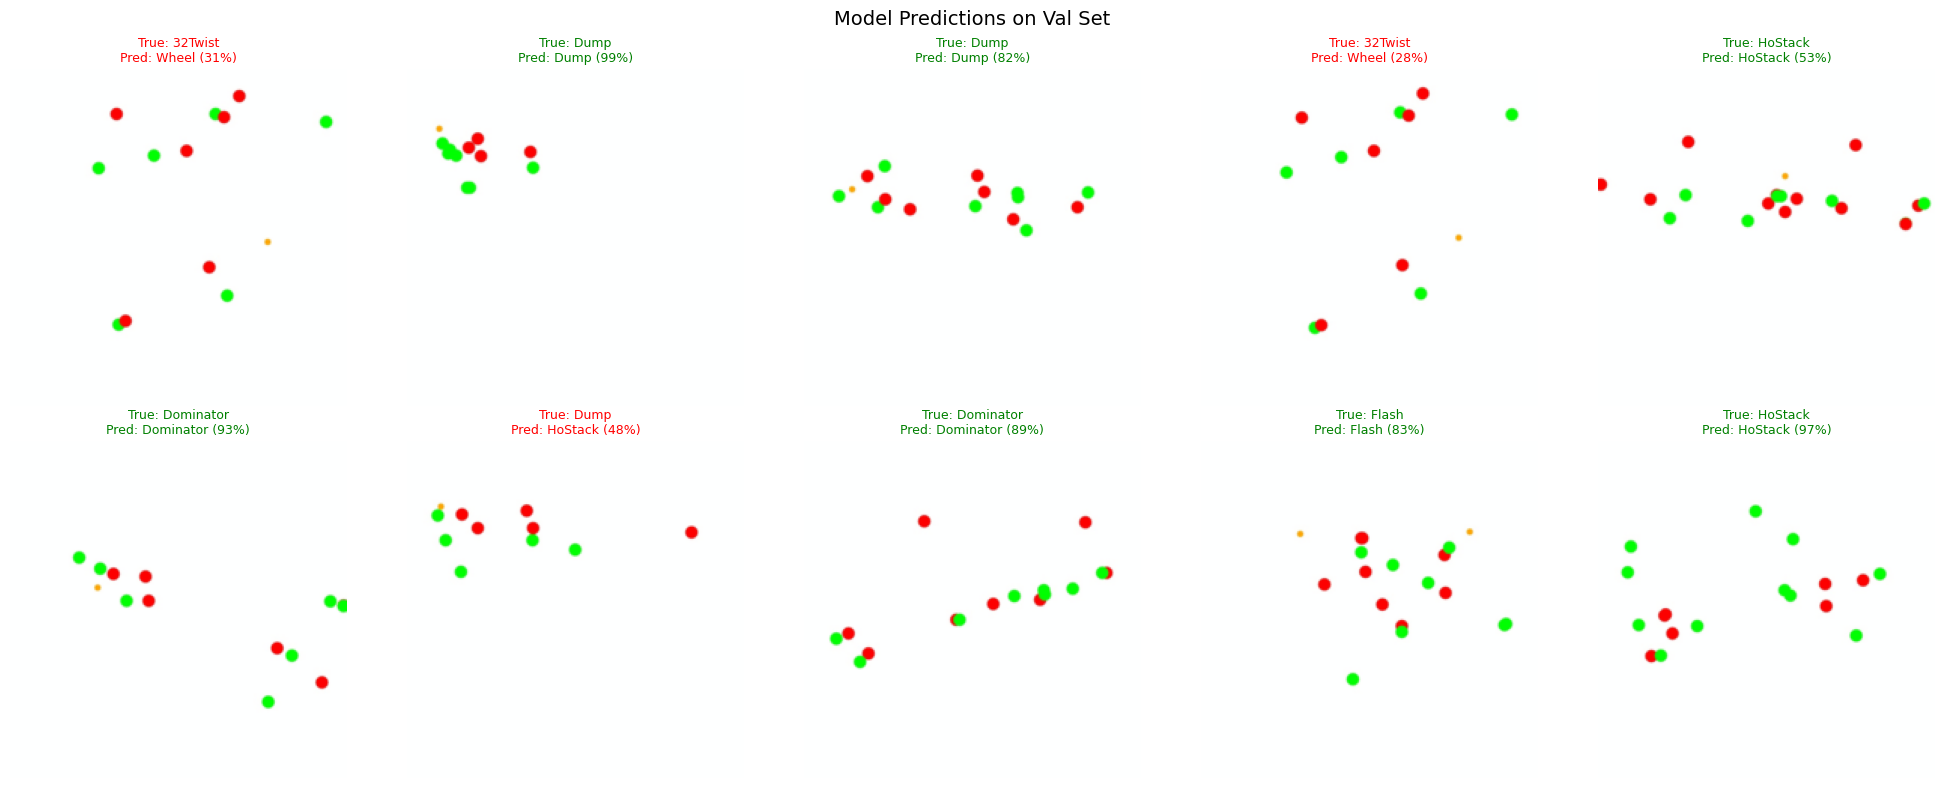

In [ ]:
import matplotlib.pyplot as plt
import random

# Check a few val samples and what the model predicts
model.eval()
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

val_classes = val_dataset.classes

for i in range(10):
    idx = random.randint(0, len(val_dataset) - 1)
    img, true_label = val_dataset[idx]

    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        probs = torch.softmax(output, dim=1)[0]
        pred_label = probs.argmax().item()
        confidence = probs.max().item()

    img_np = img.permute(1, 2, 0).numpy()
    # Unnormalize for display
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    img_np = (img_np * std + mean).clip(0, 1)

    correct = pred_label == true_label
    axes[i].imshow(img_np)
    axes[i].set_title(
        f"True: {val_classes[true_label]}\nPred: {val_classes[pred_label]} ({confidence:.0%})",
        color='green' if correct else 'red', fontsize=9
    )
    axes[i].axis('off')

plt.suptitle("Model Predictions on Val Set", fontsize=14)
plt.tight_layout()
plt.show()

**TO TEST FINAL FUNCTION WITH RESNET SEE predict_play AT TOP OF FILE**

**SAVING AND LOADING WEIGHTS FOR FUTURE SESSIONS**

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'classes': train_dataset.classes
}, '/content/drive/MyDrive/frisbee_dotmaps_cnn_resnet18.pth')

print("Saved model to Drive.")

Saved model to Drive.
